# Notebook 02:  Bias & Fairness Analysis

This notebook performs a bias and fairness analysis to the clean dataset, after the remediation steps in the previous notebooks were done (`cleaned_dataset.json`).  

The objective is to:
- Identify potential bias in historical decisions
- Find supporting/refuting evidence of that bias  
- Perform proxy discrimination analysis
- Explore potential interaction effects 
- Provide visualizations of findings


This notebook is structured as follows:

1. Gender Bias Patterns
2. Age Bias Patterns
3. Proxy Discrimination Analysis
4. Interaction Effects 
5. Bias & Fairness Analysis Summary

## 0. Imports and loading the dataset
Before performing any analysis, it is necessary to import the necessary libraries that will auxiliate in performing tasks, such libraries include pandas and numpy. It is also to load the JSON file containing the cleaned datafram from the previous notebook.

In [34]:
# Imports and loading the dataset
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the JSON 
df = pd.read_json("../data/cleaned_dataset.json")

# Convert the DataFrame into a flat list of row dictionaries
records = df.to_dict(orient='records')

# Now flatten the nested dictionaries
df_clean = pd.json_normalize(records)

# Sanity check
print("Columns in the cleaned DataFrame:")
print(df_clean.columns.tolist())


Columns in the cleaned DataFrame:
['_id', 'spending_behavior', 'processing_timestamp', 'loan_purpose', 'notes', 'applicant_info.date_of_birth_clean', 'dq_flag_duplicate_note', 'dq_flag_duplicate_ssn', 'dq_flag_duplicate_email', 'dq_duplicate_any', 'dq_action', 'dq_flag_future_processing_ts', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'applicant_info.gender_clean', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'financials.annual_salary', 'financials.annual_income_clean', 'decision.loan_approved', 'decision.rejection_reason', 'decision.interest_rate', 'decision.approved_amount']


# 1. Gender Bias Patterns 

We assess gender bias patterns primarily through the Disparate Impact Ratio. Here's the formula: 

DI = Approval rate of unprivileged group / Approval rate of previleged group

The four fifth's rule states that if one group’s approval rate is less than 80%
of another group’s rate, then there might be potential bias against the unprivileged group,  investigate for discrimination.
 
 

In [35]:
# Getting the needed elements of the Disparate Impact Ratio (DI)
approved_by_gender = df_clean.groupby("applicant_info.gender_clean")["decision.loan_approved"]
female_approved = approved_by_gender.mean().iloc[0] 
male_approved = approved_by_gender.mean().iloc[1]

# Getting the DI
gender_DI = female_approved / male_approved if males > 0 and females > 0 else 0
print(f"\nGender Disparate Impact Ratio (Female as unprivileged): {gender_DI:.2f}")

if gender_DI < 0.8: print("Warning: Potential bias detected against females.")
else:    print("No significant bias detected against females.")


Gender Disparate Impact Ratio (Female as unprivileged): 0.77


In [36]:
# Statistical test for discrimination by gender
# Basis for the test
means = approved_by_gender.mean()
totals = approved_by_gender.count()
std = approved_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between genders.")

H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.


# 2. Age Bias Patterns 

We assess age bias patterns following the same logic as the previous analysis.
 
 

In [37]:
# Approval Rates by Age Group
def calculate_exact_age(dob,now=pd.Timestamp.now()):

    # Convert the individual string to a datetime object
    d = pd.to_datetime(dob, errors='coerce')
    
    # If the date is missing/invalid, leave it as NaN
    if pd.isna(d):
        return float('nan')
    
    # Check if today's month and day are BEFORE the birth month and day
    hasnt_had_birthday = (now.month, now.day) < (d.month, d.day)
    
    # Subtract the years. If hasnt_had_birthday is True, it subtracts 1. If False, it subtracts 0.
    return now.year - d.year - int(hasnt_had_birthday)

# Creating the age column by applying the calculate_exact_age function to the date_of_birth column
df_clean["applicant_info.age"] = df_clean["applicant_info.date_of_birth_clean"].apply(calculate_exact_age)

# Creating age groups
df_clean["applicant_info.age_group"] = pd.cut(df_clean["applicant_info.age"], 
                                                 bins=[18, 30, 43, 55, np.inf], 
                                                 labels=["18-30", "31-43", "43-55", "55+"],
                                                 right=True)

# Calculating approval rates by age group
decisions_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]
print("\nAverage Approval Rates by Age Group:")
print(decisions_by_age.mean())
print("\nCounts")
print(decisions_by_age.count())


Average Approval Rates by Age Group:
applicant_info.age_group
18-30    0.412371
31-43    0.630631
43-55    0.617391
55+      0.612903
Name: decision.loan_approved, dtype: float64

Counts
applicant_info.age_group
18-30     97
31-43    222
43-55    115
55+       62
Name: decision.loan_approved, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_5304\1315253201.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decisions_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]


In [38]:
# Discrimination by Age (18-30 vs 30+)
df_clean["applicant_info.age_group"] = pd.cut(df_clean["applicant_info.age"], 
                                                 bins=[18, 30, np.inf], 
                                                 labels=["18-30", "30+"],
                                                 right=True)
approved_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]
age_DI = (approved_by_age.mean().iloc[0]) / (approved_by_age.mean().iloc[1]) if approved_by_age.mean().iloc[0] > 0 else 0

print(f"\nAge Disparate Impact Ratio (18-30 as unprivileged): {age_DI:.2f}")
if age_DI < 0.8: print("Warning: Potential bias detected against 18-30 age group.")
else:    print("No significant bias detected against 18-30 age group.")


Age Disparate Impact Ratio (18-30 as unprivileged): 0.66


C:\Users\user\AppData\Local\Temp\ipykernel_5304\3450110038.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]


In [39]:
# Statistical test for age discrimination on loan approval
# Basis for the test
means = approved_by_age.mean()
totals = approved_by_age.count()
std = approved_by_age.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between age groups.")

H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.


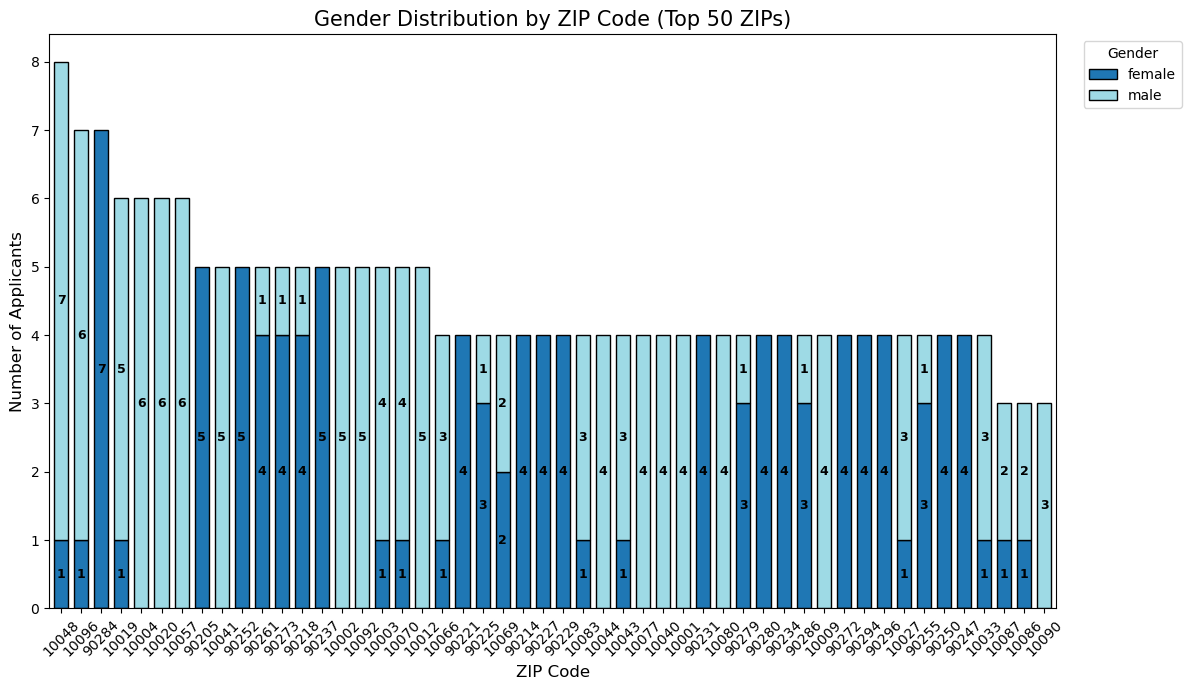

In [ ]:
# ZIP Code Distribution by Gender
# Groupby, count, and UNSTACK to create columns for genders
result = df_clean.groupby(["applicant_info.zip_code", "applicant_info.gender_clean"])["_id"].count().unstack(fill_value=0)

# Grab the ZIP Codes in ascending order of total applicants
result = result.assign(Total=result.sum(axis=1)).sort_values('Total', ascending=False).drop(columns='Total').head(50)

# Build the Stacked Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
result.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black', width=0.7)

# Adds the labels (raw counts)
for c in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black', weight='bold')

# Add Titles
ax.set_title('Gender Distribution by ZIP Code (Top 50 ZIPs)', fontsize=15)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_xlabel('ZIP Code', fontsize=12)
plt.xticks(rotation=45) 
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show() 